# State History Visualization
Visualizing how object states change over time across episodes.
Generated from `scripts/generate_scenarios.py` outpu

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter

DATA_PATH = Path('../data/episodes/scenarios/scenarios.json')
with open(DATA_PATH) as f:
    episodes = json.load(f)

print(f"Total episodes: {len(episodes)}")
print(f"Episodes with labels: {len([e for e in episodes if e['action_labels']])}")

Total episodes: 25
Episodes with labels: 23


## 1. Action Label Distribution
How often does each action type appear across all episodes?

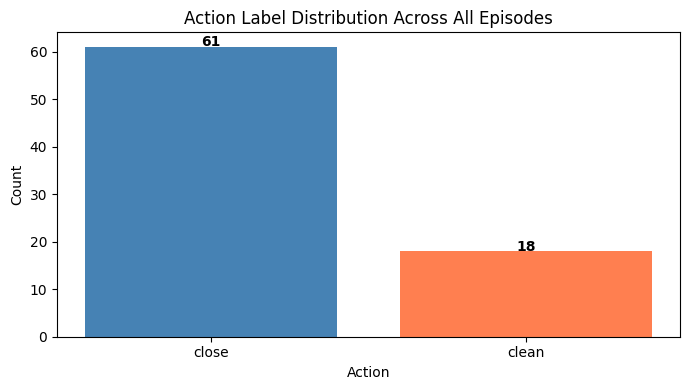

In [3]:
# count action labels across all episodes
action_counts = Counter()
for ep in episodes:
    for label in ep['action_labels']:
        action_counts[label['action']] += 1

# plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(action_counts.keys(), action_counts.values(), color=['steelblue', 'coral', 'mediumseagreen'])
ax.set_title('Action Label Distribution Across All Episodes')
ax.set_xlabel('Action')
ax.set_ylabel('Count')
for i, (k, v) in enumerate(action_counts.items()):
    ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/episodes/scenarios/action_distribution.png', dpi=150)
plt.show()

## 2. Object Type Frequency
Which object types appear most often as needing action?

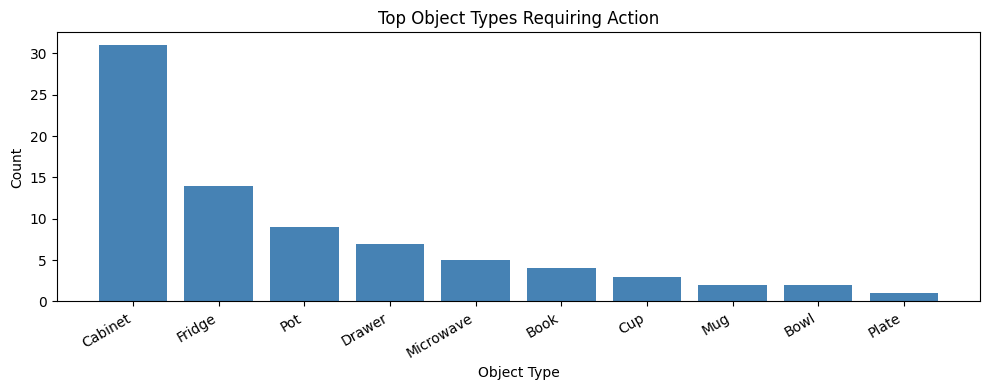

In [4]:
# which object types need action most
object_counts = Counter()
for ep in episodes:
    for label in ep['action_labels']:
        object_counts[label['object_type']] += 1

# top 10
top_objects = dict(object_counts.most_common(10))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(top_objects.keys(), top_objects.values(), color='steelblue')
ax.set_title('Top Object Types Requiring Action')
ax.set_xlabel('Object Type')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/episodes/scenarios/object_frequency.png', dpi=150)
plt.show()

## 3. State Sequence Heatmap
For a single episode, visualize the state of each object type over the sequence.
`1` = True, `0` = False, `-1` = None

Visualizing Episode 21 (FloorPlan5, 10 labels)


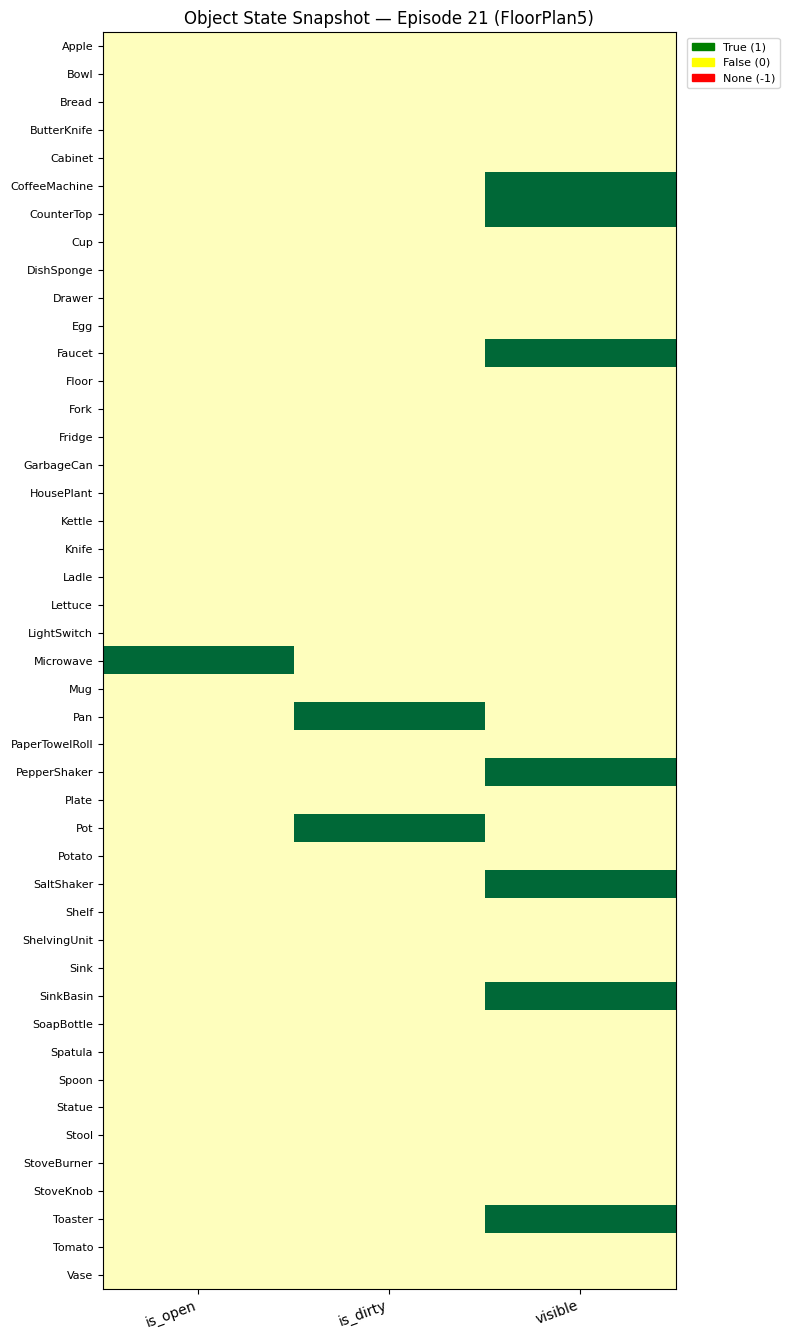

In [7]:
# pick episode with most labels for visualization
ep = max(episodes, key=lambda e: len(e['action_labels']))
print(f"Visualizing Episode {ep['episode_id']} "
      f"({ep['floor_plan']}, {len(ep['action_labels'])} labels)")

# build state matrix
seq = ep['state_sequence']
object_types = list(dict.fromkeys([s['object_type'] for s in seq]))

def bool_to_int(val):
    if val is True:  return 1
    if val is False: return 0
    return -1

fields = ['is_open', 'is_dirty', 'visible']
rows, row_labels = [], []
for obj_type in object_types:
    obj_states = [s for s in seq if s['object_type'] == obj_type]
    if not obj_states:
        continue
    s = obj_states[0]
    row = [bool_to_int(s[f]) for f in fields]
    rows.append(row)
    row_labels.append(obj_type)

import numpy as np
matrix = np.array(rows)

fig, ax = plt.subplots(figsize=(8, max(6, len(row_labels) * 0.3)))
im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(fields)))
ax.set_xticklabels(fields, rotation=20, ha='right')
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=8)
ax.set_title(f"Object State Snapshot — Episode {ep['episode_id']} ({ep['floor_plan']})")

# legend
patches = [
    mpatches.Patch(color='green',  label='True (1)'),
    mpatches.Patch(color='yellow', label='False (0)'),
    mpatches.Patch(color='red',    label='None (-1)'),
]
ax.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('../data/episodes/scenarios/state_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Action Labels per Floor Plan
Does the number of required actions vary by environment?

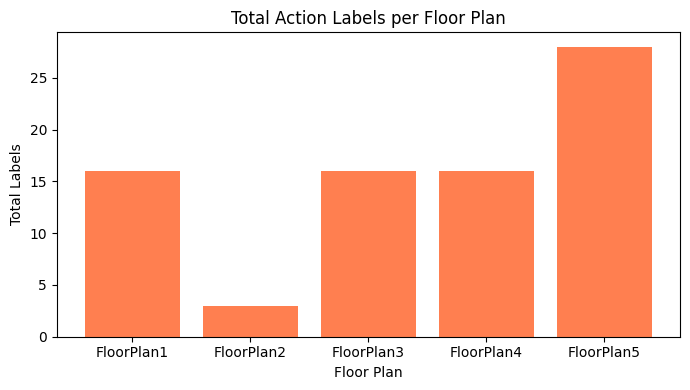

In [9]:
fps    = sorted(fp_counts.keys())
totals = [sum(fp_counts[fp]) for fp in fps]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(fps, totals, color='coral')
ax.set_title('Total Action Labels per Floor Plan')
ax.set_ylabel('Total Labels')
ax.set_xlabel('Floor Plan')
plt.tight_layout()
plt.savefig('../data/episodes/scenarios/labels_per_floorplan.png', dpi=150)
plt.show()

## Summary
- Action label distribution shows class balance across episodes
- Object frequency reveals which items most commonly need attention
- State heatmap shows per-object state snapshot for a single episode
- Floor plan analysis confirms data is spread across environments

These visualizations inform D4 data collection strategy and D5 model training.